In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import numpy as np
import matplotlib.pyplot as plt     
from PostprocessingFunctions import write_vtk

In [38]:
%%bash
cd ..
g++ -std=c++17 -Wall Ramp.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o RampMMS 

        

SRC/Flux.cpp: In function ‘double p_func(double, double, double, double)’:
SRC/Flux.cpp:407:10: warning: unused variable ‘den’ [-Wunused-variable]
  407 |     auto den = (1+r > 0) - (1+r < 0);
      |          ^~~
SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:431:26: warning: unused variable ‘tol’ [-Wunused-variable]
  431 |             const double tol = 1e-14;
      |                          ^~~
SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:568:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  568 |         bool ghost_flag = false;
      |              ^~~~~~~~~~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:173:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  173 |     double gamma = 1.4;
      |            ^~~~~


In [39]:
%%bash
cd ..
./RampMMS

Shape = (832, 4)
setting pointersSetting ambient Conditions...Setting inflow Conditions...Freestream Pressure: 80.8113   Freestream Density: 0.00544979 Freestream vel576.329Iteration: 0
Upwind Order: 0;  Norms:
  Density   : 0.000262441  U-velocity: 0.151252  V-velocity: 1.59665e-17  Pressure  : 57.2059
Iteration: 1
Upwind Order: 0;  Norms:
  Density   : 0.000262108  U-velocity: 0.150548  V-velocity: 0.000862765  Pressure  : 57.1265
Iteration: 2
Upwind Order: 0;  Norms:
  Density   : 0.000261781  U-velocity: 0.149842  V-velocity: 0.00173325  Pressure  : 57.0483
Iteration: 3
Upwind Order: 0;  Norms:
  Density   : 0.000261458  U-velocity: 0.149135  V-velocity: 0.00261181  Pressure  : 56.9713
Iteration: 4
Upwind Order: 0;  Norms:
  Density   : 0.00026114  U-velocity: 0.148425  V-velocity: 0.00349874  Pressure  : 56.8952
Iteration: 5
Upwind Order: 0;  Norms:
  Density   : 0.000260827  U-velocity: 0.147713  V-velocity: 0.00439425  Pressure  : 56.8201
Iteration: 6
Upwind Order: 0;  Norms:
  

Upwind Order: 0;  Norms:
  Density   : 0.000259312  U-velocity: 0.144107  V-velocity: 0.00900513  Pressure  : 56.4558
Iteration: 11
Upwind Order: 0;  Norms:
  Density   : 0.000259019  U-velocity: 0.143376  V-velocity: 0.00995447  Pressure  : 56.3848
Iteration: 12
Upwind Order: 0;  Norms:
  Density   : 0.000258727  U-velocity: 0.14264  V-velocity: 0.0109129  Pressure  : 56.3143
Iteration: 13
Upwind Order: 0;  Norms:
  Density   : 0.000258438  U-velocity: 0.141901  V-velocity: 0.0118805  Pressure  : 56.2443
Iteration: 14
Upwind Order: 0;  Norms:
  Density   : 0.000258152  U-velocity: 0.141157  V-velocity: 0.0128571  Pressure  : 56.1747
Iteration: 15
Upwind Order: 0;  Norms:
  Density   : 0.000257867  U-velocity: 0.14041  V-velocity: 0.0138428  Pressure  : 56.1055
Iteration: 16
Upwind Order: 0;  Norms:
  Density   : 0.000257584  U-velocity: 0.139659  V-velocity: 0.0148376  Pressure  : 56.0366
Iteration: 17
Upwind Order: 0;  Norms:
  Density   : 0.000257304  U-velocity: 0.138903  V-velocit

In [40]:


data = np.loadtxt("../primitives.csv", delimiter=",")
NI = 16
NJ = 52
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 832)


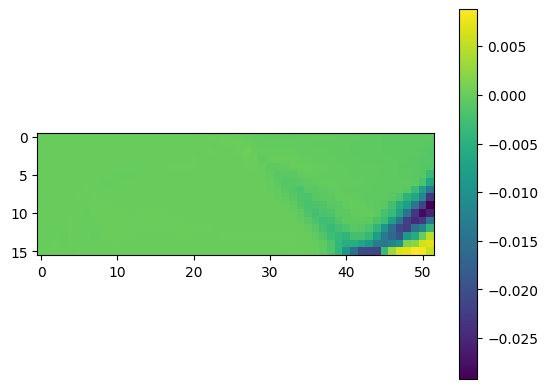

In [41]:
plt.imshow(u[::-1])
plt.colorbar()

In [42]:
from PostprocessingFunctions import load_grid
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.53x17.grd")



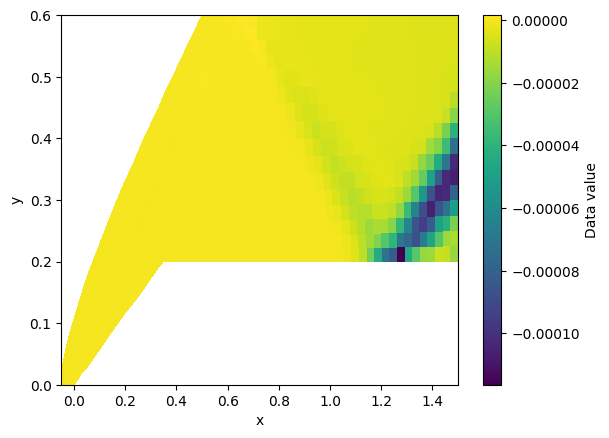

In [43]:
 

plt.pcolormesh(x, y, rho, shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



In [44]:
write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.209x65.grd",rho,u,v,p,output_name="../VTK/Fine_Ramp.vtk")

ValueError: Input point array shapes must match exactly